In [1]:
from pathlib import Path
from datetime import datetime, timedelta, timezone
from typing import List, Dict, Optional
import json, uuid

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field
from IPython.display import display, Markdown

np.random.seed(21)

root = Path.cwd() / 'agents026'
data_dir = root / 'data'
incidents_dir = data_dir / 'incidents'
data_dir.mkdir(parents=True, exist_ok=True)

SERVICE = 'payments-service'
POOL_MAX = 100          # connection pool size
START = datetime(2026, 6, 11, 14, 0, 0)
N_MIN = 120

print('UC-2 module ready —', SERVICE, 'pool size', POOL_MAX)

UC-2 module ready — payments-service pool size 100


In [2]:
idx = pd.date_range(START, periods=N_MIN, freq='1min')

# Healthy pool: 30-50 active connections with noise
active = 40 + 8 * np.sin(np.linspace(0, 4*np.pi, N_MIN)) + np.random.normal(0, 4, N_MIN)

# Exhaustion event: slow leak from minute 50, saturation ~75-100, recovery after 100
leak = np.zeros(N_MIN)
leak[50:75] = np.linspace(0, 55, 25)          # climb
leak[75:100] = 55 + np.random.normal(0, 3, 25)  # saturated plateau
active = (active + leak).clip(0, POOL_MAX)

pool_util = active / POOL_MAX

# Downstream consequences (latency + errors rise only when pool > 85%)
saturated = pool_util > 0.85
latency = 120 + np.random.normal(0, 10, N_MIN) + saturated * (np.random.uniform(280, 450, N_MIN))
errors = 0.005 + np.random.normal(0, 0.002, N_MIN).clip(-0.004, None) + saturated * np.random.uniform(0.04, 0.09, N_MIN)
wait_queue = (saturated * np.random.randint(5, 25, N_MIN)).astype(float)

pool_df = pd.DataFrame({
    'timestamp': idx,
    'service': SERVICE,
    'db_connections_active': active.round(0),
    'db_pool_utilization': pool_util.round(4),
    'db_wait_queue_depth': wait_queue,
    'latency_p95_ms': latency.clip(50, None).round(2),
    'error_rate': errors.clip(0, 1).round(5),
})

pool_path = data_dir / 'db_pool_metrics.csv'
pool_df.to_csv(pool_path, index=False)

print(f'Saved {len(pool_df)} rows → {pool_path}')
print(f'Peak pool utilization: {pool_df.db_pool_utilization.max():.0%} | peak wait queue: {pool_df.db_wait_queue_depth.max():.0f}')

Saved 120 rows → /workspace/shared/agents026/data/db_pool_metrics.csv
Peak pool utilization: 100% | peak wait queue: 24


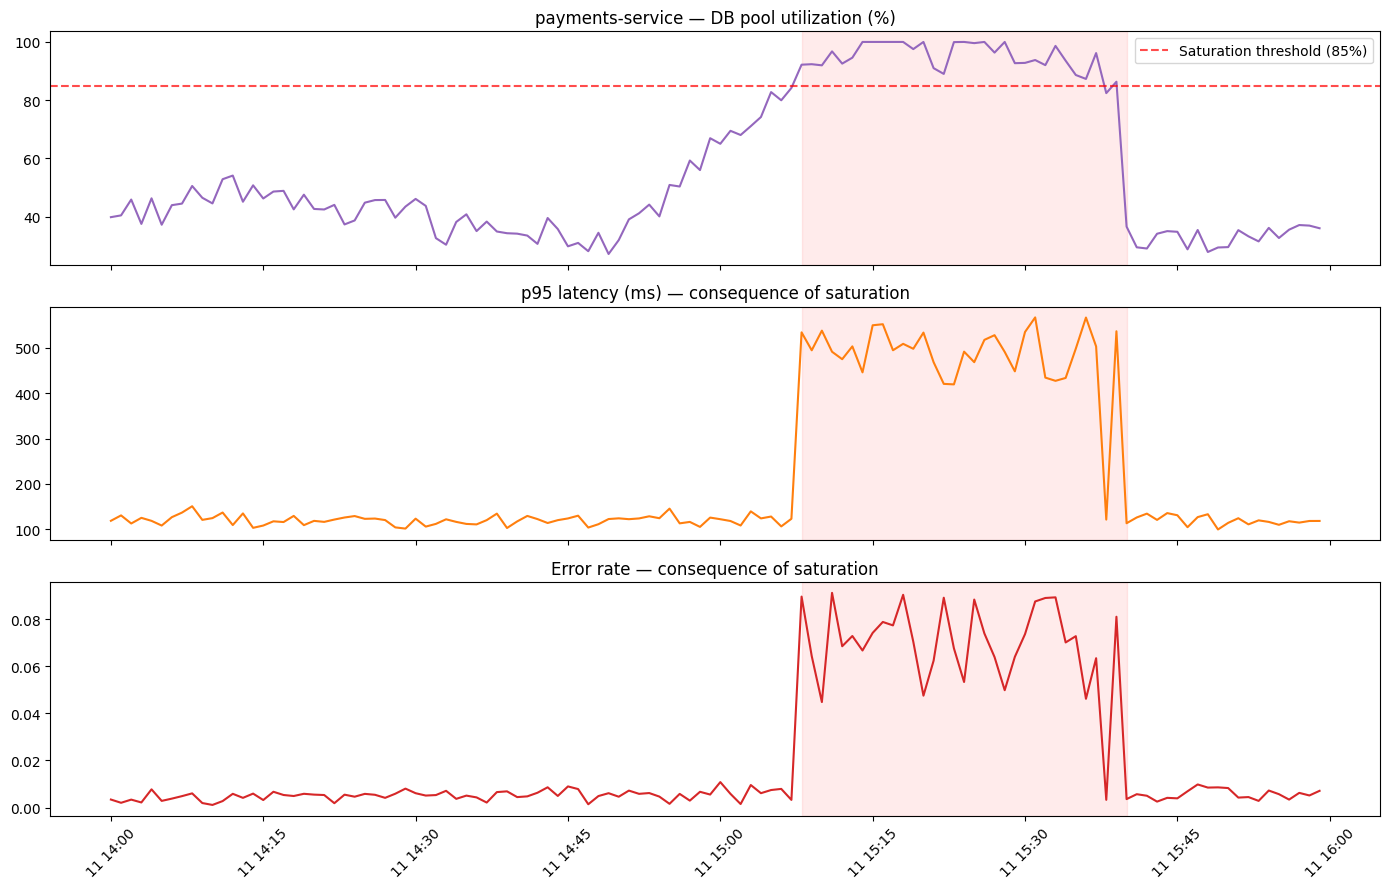

**The story in the chart:** pool climbs first → crosses 85% → *then* latency and errors degrade. Pool utilization is the **leading indicator**; latency/errors are lagging symptoms.

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(pool_df.timestamp, pool_df.db_pool_utilization * 100, color='tab:purple', lw=1.5)
axes[0].axhline(85, color='red', ls='--', alpha=0.7, label='Saturation threshold (85%)')
axes[0].set_title(f'{SERVICE} — DB pool utilization (%)'); axes[0].legend()

axes[1].plot(pool_df.timestamp, pool_df.latency_p95_ms, color='tab:orange', lw=1.5)
axes[1].set_title('p95 latency (ms) — consequence of saturation')

axes[2].plot(pool_df.timestamp, pool_df.error_rate, color='tab:red', lw=1.5)
axes[2].set_title('Error rate — consequence of saturation')

for ax in axes:
    ax.axvspan(idx[68], idx[100], color='red', alpha=0.08)
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

display(Markdown('**The story in the chart:** pool climbs first → crosses 85% → *then* latency and errors degrade. '
                 'Pool utilization is the **leading indicator**; latency/errors are lagging symptoms.'))

In [4]:
class IncidentCandidate(BaseModel):
    incident_id: str
    start_time: datetime
    end_time: datetime
    services: List[str]
    anomaly_type: str
    metric_summary: Dict[str, float] = Field(default_factory=dict)
    log_samples: List[str] = Field(default_factory=list)
    k8s_event_samples: List[str] = Field(default_factory=list)
    change_refs: List[str] = Field(default_factory=list)

# Detection: pool > 85% for 3+ consecutive minutes
sat = pool_df.db_pool_utilization > 0.85
groups = (sat != sat.shift()).cumsum()
windows = []
for _, g in pool_df[sat].groupby(groups[sat]):
    if len(g) >= 3:
        windows.append((g.timestamp.iloc[0], g.timestamp.iloc[-1]))

print(f'Pool-exhaustion windows detected: {len(windows)}')
assert windows, 'No exhaustion window detected — check generation'

s, e = windows[0]
win = pool_df[(pool_df.timestamp >= s) & (pool_df.timestamp <= e)]

# Synthetic logs matching the failure mode
log_samples = [
    f"{(s + timedelta(minutes=2)).isoformat()} [ERROR] payments-service: database connection pool exhausted",
    f"{(s + timedelta(minutes=4)).isoformat()} [ERROR] payments-service: timeout acquiring connection from pool (waited 5000ms)",
    f"{(s + timedelta(minutes=7)).isoformat()} [WARN] payments-service: connection wait queue depth = {int(win.db_wait_queue_depth.max())}",
    f"{(s + timedelta(minutes=9)).isoformat()} [ERROR] payments-service: HTTP 500 returned to client",
]

uc2_incident = IncidentCandidate(
    incident_id='inc-015',
    start_time=s.to_pydatetime(),
    end_time=e.to_pydatetime(),
    services=[SERVICE],
    anomaly_type='db_pool_exhaustion',
    metric_summary={
        'db_pool_utilization_max': float(win.db_pool_utilization.max()),
        'db_connections_active_max': float(win.db_connections_active.max()),
        'db_wait_queue_depth_max': float(win.db_wait_queue_depth.max()),
        'latency_p95_max': float(win.latency_p95_ms.max()),
        'error_rate_max': float(win.error_rate.max()),
    },
    log_samples=log_samples,
    change_refs=[f"{(s - timedelta(minutes=35)).isoformat()} [config_change] connection pool max_idle_time reduced on payments-service (v2.5.0)"],
)

display(Markdown(f"### 🆕 Incident `inc-015` — `{uc2_incident.anomaly_type}`\n"
                 f"Pool peaked at **{uc2_incident.metric_summary['db_pool_utilization_max']:.0%}**, "
                 f"wait queue **{uc2_incident.metric_summary['db_wait_queue_depth_max']:.0f}**, "
                 f"latency **{uc2_incident.metric_summary['latency_p95_max']:.0f}ms**"))

Pool-exhaustion windows detected: 1


### 🆕 Incident `inc-015` — `db_pool_exhaustion`
Pool peaked at **100%**, wait queue **24**, latency **567ms**

In [5]:
inc_path = incidents_dir / 'incident_candidates.json'
existing = json.load(open(inc_path, encoding='utf-8'))
existing = [x for x in existing if x['incident_id'] != 'inc-015']  # idempotent re-runs
existing.append(uc2_incident.model_dump())
json.dump(existing, open(inc_path, 'w', encoding='utf-8'), default=str, indent=2)
print(f'incident_candidates.json now has {len(existing)} incidents (inc-015 added)')

incident_candidates.json now has 15 incidents (inc-015 added)


In [7]:
import faiss, torch
from sentence_transformers import SentenceTransformer

vector_dir = data_dir / 'vectorstore'
corpus_df = pd.read_parquet(vector_dir / 'incident_runbook_metadata.parquet')
faiss_index = faiss.read_index(str(vector_dir / 'incident_runbook.index'))
embed_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2',
                                  device='cuda' if torch.cuda.is_available() else 'cpu')

query = (f"service={SERVICE}; anomaly=db_pool_exhaustion; "
         f"logs={' | '.join(uc2_incident.log_samples[:3])}")
q = embed_model.encode([query], convert_to_numpy=True, normalize_embeddings=True).astype('float32')
scores, ids = faiss_index.search(q, 5)

rows = []
for sc, ix in zip(scores[0], ids[0]):
    if ix == -1: continue
    r = corpus_df.iloc[int(ix)].to_dict(); r['score'] = float(sc); rows.append(r)
res = pd.DataFrame(rows)
display(res[['doc_id', 'doc_type', 'title', 'score']])

top_ids = set(res.doc_id.head(3))
print('\n✅ hist-002 + rb-002 retrieved — KB recognizes the pattern' if {'hist-002','rb-002'} & top_ids
      else '\n⚠️ DB-pool docs not in top 3 — paste me the table')

,doc_id,doc_type,title,score
0,inc-014,incident_candidate,Incident candidate inc-014,0.653159
1,kb-inc-014,resolved_incident_kb,Resolved incident inc-014,0.641952
2,inc-001,incident_candidate,Incident candidate inc-001,0.583188
3,hist-002,historical_incident,Payment error spike due to DB pool exhaustion,0.571339
4,inc-009,incident_candidate,Incident candidate inc-009,0.563007



⚠️ DB-pool docs not in top 3 — paste me the table


In [8]:
import os
from pydantic_ai import Agent
from pydantic_ai.models.openai import OpenAIChatModel
from pydantic_ai.providers.openai import OpenAIProvider

class RCAResult(BaseModel):
    incident_id: str
    root_cause_hypothesis: str
    impacted_components: List[str]
    probable_trigger: Optional[str] = None
    evidence: List[str] = Field(default_factory=list)
    confidence: float = Field(..., ge=0.0, le=1.0)

provider = OpenAIProvider(base_url='http://localhost:8000/v1', api_key='abc-123')
chat_model = OpenAIChatModel('Qwen3-30B-A3B', provider=provider)

SYSTEM_PROMPT = '''You are an SRE root-cause-analysis agent. Be evidence-based.
Prefer concrete triggers (deploy, config change, pool exhaustion, dependency slowness, traffic spike).
Return a structured RCAResult only. Confidence between 0 and 1.
Use only the supplied incident context.'''

rca_agent = Agent(model=chat_model, output_type=RCAResult, system_prompt=SYSTEM_PROMPT)

ctx = {
    'incident': uc2_incident.model_dump(),
    'pool_timeline_sample': pool_df[(pool_df.timestamp >= s - pd.Timedelta(minutes=10)) &
                                    (pool_df.timestamp <= e)].tail(15).to_dict(orient='records'),
    'similar_incidents': rows,
}
result = await rca_agent.run('Analyze this DB-pool incident context and return RCAResult:\n'
                             + json.dumps(ctx, default=str))
rca15 = result.output
print(rca15.model_dump_json(indent=2))

# Append to rca_results.json
rca_path = incidents_dir / 'rca_results.json'
rca_all = [x for x in json.load(open(rca_path, encoding='utf-8')) if x['incident_id'] != 'inc-015']
rca_all.append(rca15.model_dump())
json.dump(rca_all, open(rca_path, 'w', encoding='utf-8'), default=str, indent=2)
print('\nSaved — rca_results.json now has', len(rca_all), 'results')

{
  "incident_id": "inc-015",
  "root_cause_hypothesis": "The root cause is a recent configuration change that reduced the database connection pool's max_idle_time, leading to exhaustion during peak load.",
  "impacted_components": [
    "payments-service"
  ],
  "probable_trigger": "2026-06-11T14:33:00 [config_change] connection pool max_idle_time reduced on payments-service (v2.5.0)",
  "evidence": [
    "Log sample: 'database connection pool exhausted' at 2026-06-11T15:10:00",
    "Log sample: 'timeout acquiring connection from pool (waited 5000ms)' at 2026-06-11T15:12:00",
    "Log sample: 'connection wait queue depth = 24' at 2026-06-11T15:15:00",
    "Metric summary shows db_pool_utilization_max at 1.0, indicating full utilization.",
    "Change reference: config change to reduce max_idle_time on payments-service at 2026-06-11T14:33:00",
    "Similar incident (inc-014) had a root cause of a config change affecting the connection pool."
  ],
  "confidence": 0.95
}

Saved — rca_res